# REG. LINEAL VS. LSTM VS. GRU

En este notebook desarrollamos tres modelos predictivos (rgresión lineal múltiple, LSTM y GRU), con el objetivo de compararlos. 

El problema a tratar es la predicción del precio de cierre del índice SP500. 
Utilizaremos la libreria yfinance para obtener los datos, y nos quedaremos con los últimos 12 años de registros. Además, observamos que hay días no incluidos. Estos días son fines de semana y festivos en los que el mercado está cerrado. En proyectos de Machine Learning financiero no se usa el calendario natural, sino el de "Trading Days".

In [62]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



from tensorflow.keras.layers import GRU
# Reproducibilidad
tf.keras.utils.set_random_seed(42)
# Reproducibilidad

ticker    = '^GSPC'        # Acción a predecir
start  = '2014-01-01'  # Inicio del histórico
end   = '2026-01-01'  # Fin del histórico
tiempo = 30       # Días usados para predecir el siguiente
test_final=60

df = yf.download(ticker, start=start, end=end)

data = df[['Close']].copy()
data.dropna(inplace=True)
data.columns = data.columns.get_level_values(0)

#Nos quedamos solo con el primer nivel (Close, Open, etc.), elimino el ticker porque me va a dar problemas después.
df.columns = df.columns.get_level_values(0)
#Ahora tenemos 5 atributos y 3018 datos.
df = df.reset_index()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2014-01-02,1831.979980,1845.859985,1827.739990,1845.859985,3080600000
1,2014-01-03,1831.369995,1838.239990,1829.130005,1833.209961,2774270000
2,2014-01-06,1826.770020,1837.160034,1823.729980,1832.310059,3294850000
3,2014-01-07,1837.880005,1840.099976,1828.709961,1828.709961,3511750000
4,2014-01-08,1837.489990,1840.020020,1831.400024,1837.900024,3652140000


Usamos el método info() para ver si hay valores nulos (en este caso no hay), el tipado de cada atributo, etc. Y vemos que todos los atributos son numéricos.

In [63]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3018 non-null   datetime64[ns]
 1   Close   3018 non-null   float64       
 2   High    3018 non-null   float64       
 3   Low     3018 non-null   float64       
 4   Open    3018 non-null   float64       
 5   Volume  3018 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 141.6 KB


Usamos ahora el método describe(), que muestra un resumen de la "distribución" de los datos: media, mediana, desviación típica... 

Observamos además que VolumeMin = 0 y el S&P 500 nunca tiene volumen cero en un día de trading normal. Probablemente corresponde a algún error en la descarga de yfinance o a un día festivo mal registrado. Por lo que hay que revisar estos días: si son errores, podemos eliminarlos o rellenarlos con la mediana.

In [64]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,3018,3018.000000,3018.000000,3018.000000,3018.000000,3.018000e+03
mean,2019-12-30 16:40:33.399602688,3474.133077,3491.834877,3453.828727,3473.566942,4.043852e+09
min,2014-01-02 00:00:00,1741.890015,1755.790039,1737.920044,1743.819946,0.000000e+00
25%,2016-12-29 06:00:00,2264.137512,2271.837524,2258.259949,2267.052551,3.406532e+09
50%,2019-12-30 12:00:00,3004.280029,3016.190063,2989.734985,3004.170044,3.835995e+09
75%,2022-12-27 18:00:00,4379.797363,4409.619995,4356.070068,4380.849976,4.466820e+09
max,2025-12-31 00:00:00,6932.049805,6945.770020,6921.600098,6936.020020,9.976520e+09
std,NaN,1353.254009,1359.846068,1345.706021,1353.046445,1.006061e+09


Ahora hacemos algunos histogramas: muestran el número de ejemplos (eje Y) que devuelven el valor en un determinado rango (eje X).

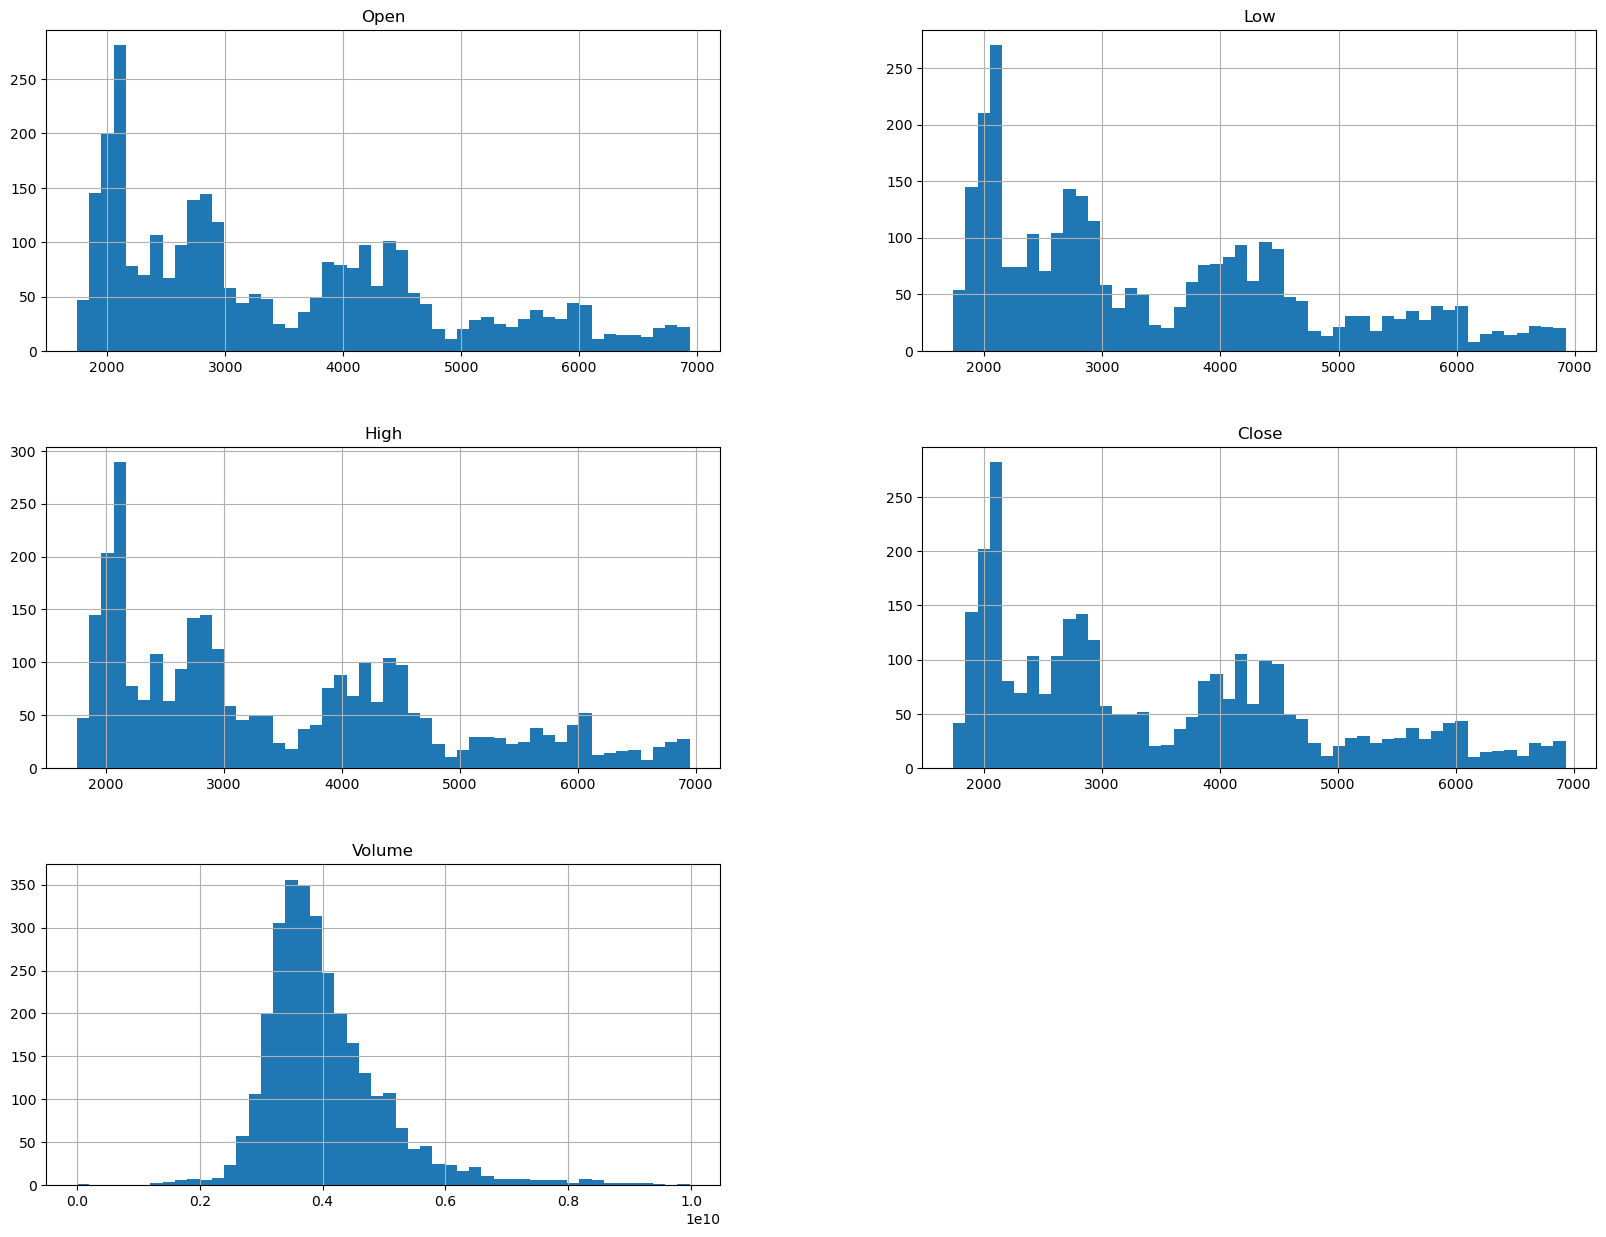

In [65]:
import matplotlib.pyplot as plt
%matplotlib inline
df[['Open', 'Low', 'High', 'Close', 'Volume']].hist(bins=50, figsize=(20,15))
plt.show()

Ahora vamos a analizar el problema de ese 0 en la variable volumen. Obtenemos que el día en cuestión es el 24 de mayo de 2023. Este día fue un miércoles normal de mercado; el S&P 500 operó con normalidad. Por tato un 0 ahí es un error de pérdida de datos en la descarga, y lo sustituiremos por la mediana.

In [66]:
dias_con_vol0 = df[df['Volume'] == 0]
print(dias_con_vol0)

Price       Date        Close         High         Low         Open  Volume
2364  2023-05-24  4115.240234  4132.959961  4103.97998  4132.959961       0


In [67]:
median_volume = df[df['Volume'] > 0]['Volume'].median()
df.loc[df['Volume'] == 0, 'Volume'] = median_volume
#Efectivamente ahora ya no hay ningún día con volumen 0.

## EXPERIMENTO 1: REGRESIÓN LINEAL MÚLTIPLE


A continuación vamos a desarrollar el mismo experimento pero usando un modelo de RNN: las LSTM. Así, intentaremos comparar cuál de los dos modelos actúa mejor frente a estos datos: ¿el modelo simple o el más complejo?

Ahora empezamos con el modelo de regresión lineal:


-Variable respuesta: Close(t)


-Variables predictoras: Close(t-1),Close(t-2),...,Close(t-30) (30 predictoras).

Por tanto vamos a visualizar ahora el precio de cierre histórico:

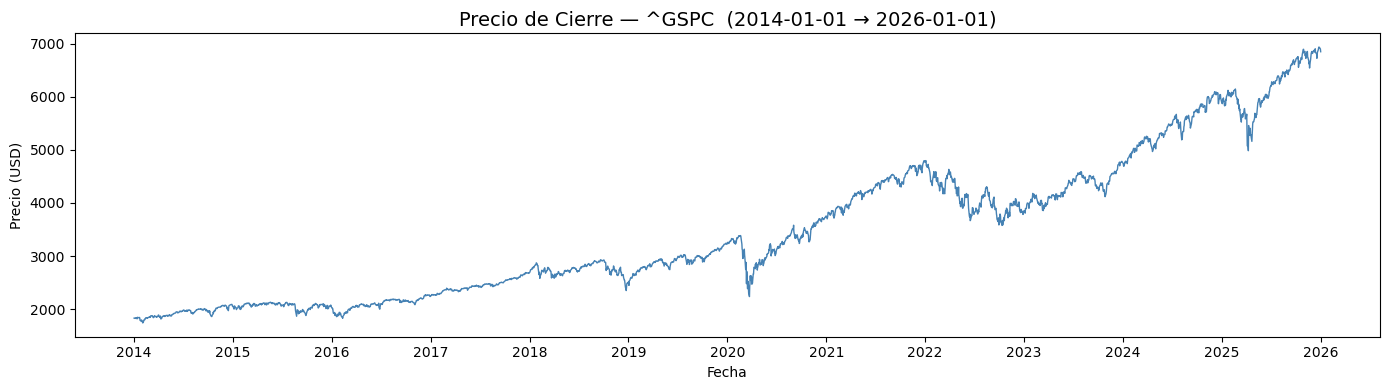

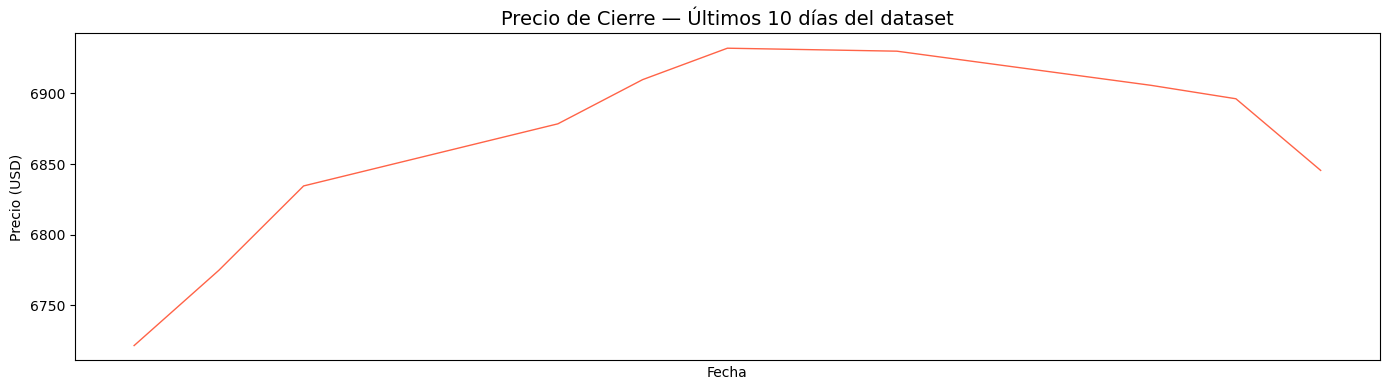

In [68]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data.index, data['Close'], color='steelblue', linewidth=1)
ax.set_title(f'Precio de Cierre — {ticker}  ({start} → {end})', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data.index[-10:], data['Close'][-10:], color='tomato', linewidth=1)
ax.set_title(f'Precio de Cierre — Últimos 10 días del dataset', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


Vemos que tiene una clara tendencia alcista, y además los valores entre un día y el siguiente tienen muy poca diferencia.

Vamos a crear las secuencias con las que trabajará el modelo de regresión lineal:

In [69]:
def create_sequences(data, tiempo):
    """
    X[i]: precios de los días [i, i+tiempo)  
    y[i]: precio del día i+tiempo        
    """
    X, y = [], []
    for i in range(tiempo, len(data)):
        X.append(data[i - tiempo:i])
        y.append(data[i])
    return np.array(X), np.array(y)


close_raw = data['Close'].values   # precios en USD
X_raw, y_raw = create_sequences(close_raw, tiempo)
X,y=X_raw[:-test_final],y_raw[:-test_final]

print(f'Total de secuencias: {len(X_raw)}')

Total de secuencias: 2988


Ahora hacemos la división en conjunto de entrenamiento y conjunto de validación (tanto para las variables predictoras como para la respuesta):

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(f'  Train             : {len(X_train)} muestras  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validación        : {len(X_test)}  muestras  ({len(X_test)/len(X)*100:.1f}%)')
print()
print(f'Rango de precios en TRAIN: [{X_train.min():.2f}, {X_train.max():.2f}] USD')
print(f'Rango de precios en VAL : [{X_test.min():.2f},  {X_test.max():.2f}] USD')
print()

  Train             : 2342 muestras  (80.0%)
  Validación        : 586  muestras  (20.0%)

Rango de precios en TRAIN: [1741.89, 6715.35] USD
Rango de precios en VAL : [1741.89,  6715.79] USD



No teníamos datos faltantes ni variables categóricas, por lo que lo único que nos queda por solucionar es la escala. Usaremos la estandarización. 

Realmente la regresión no es tan sensible a la escala, pero lo hacemos para comparar después con otros modelos.

In [71]:
scaler = StandardScaler()
# fit SOLO sobre los valores de entrenamiento
all_train_values = np.concatenate([X_train.flatten(), y_train])
scaler.fit(all_train_values.reshape(-1, 1))

# Transformar train
X_train = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
y_train = scaler.transform(y_train.reshape(-1, 1)).flatten()

# Transformar test (solo transform, nunca fit)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_test  = scaler.transform(y_test.reshape(-1, 1)).flatten()

Vamos ya con el entrenamiento del modelo:

In [72]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Vamos a predecir cada día del conjunto de validación usando los valores REALES de los 30 días anteriores y evaluamos sobre todo el conjunto (586 días).

In [73]:
y_pred_lr_scaled = lr_model.predict(X_test)

# Desescalar a USD
y_test_real    = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lr_real = scaler.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).flatten()

# Métricas
mae_lr   = mean_absolute_error(y_test_real, y_pred_lr_real)
rmse_lr  = np.sqrt(mean_squared_error(y_test_real, y_pred_lr_real))


print(f'MAE  (Error Absoluto Medio)        : {mae_lr:.4f} USD')
print(f'RMSE (Raíz Error Cuadrático Medio) : {rmse_lr:.4f} USD')

MAE  (Error Absoluto Medio)        : 25.7785 USD
RMSE (Raíz Error Cuadrático Medio) : 38.8847 USD


Vamos a predecir también con el modelo naive, que predice siempre el valor del día anterior. Es un baseline adecuado pues el SP500 es prácticamente un 'random walk'.

In [74]:
# NAIVE one-step (cada día = precio real del día anterior)
pred_naive_scaled = X_test[:, -1]
pred_naive_real   = scaler.inverse_transform(pred_naive_scaled.reshape(-1, 1)).flatten()

rmse_naive = np.sqrt(mean_squared_error(y_test_real, pred_naive_real))
mae_naive  = mean_absolute_error(y_test_real, pred_naive_real)

print(f"NAIVE one-step  RMSE: {rmse_naive:.4f} | MAE: {mae_naive:.4f}")

NAIVE one-step  RMSE: 38.1229 | MAE: 25.2841


Visualizamos el resultado de la predicción sobre los últimos 60 días que apartamos al prinipio. Se ve que la predicción sigue razonablemente bien la curva real, pero con un 'lag' característico: el modelo parece ir un paso por detrás del mercado, porque básicamente aprende que el mejor predictor de hoy es el valor de ayer.

In [75]:
close_fin = close_raw[-(test_final + tiempo):]
dates_fin = data.index[-(test_final + tiempo):]


X_fin_raw, y_fin_raw = create_sequences(close_fin, tiempo)
dates_fin_pred = dates_fin[tiempo:]   # fechas de cada predicción

# Escalar con el mismo scaler (ajustado solo sobre train)
X_fin      = scaler.transform(X_fin_raw.reshape(-1, 1)).reshape(X_fin_raw.shape)
y_fin_real = y_fin_raw   # mantener en USD para la gráfica

# Predicciones Regresión Lineal
y_fin_lr_scaled = lr_model.predict(X_fin)
y_fin_lr_real   = scaler.inverse_transform(y_fin_lr_scaled.reshape(-1, 1)).flatten()


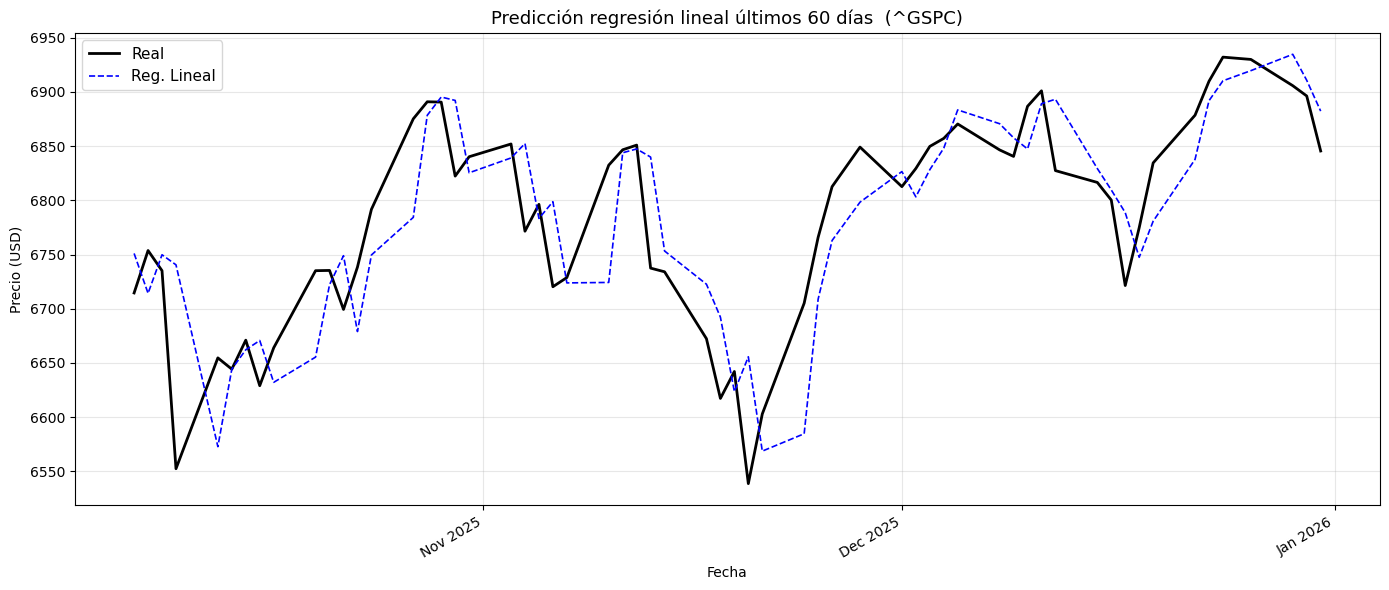

In [76]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_fin_pred, y_fin_real,      color='black',  linewidth=2,   label='Real')
ax.plot(dates_fin_pred, y_fin_lr_real,   color='blue',  linewidth=1.2, linestyle='--', label='Reg. Lineal')

ax.set_title(f'Predicción regresión lineal últimos {test_final} días  ({ticker})', fontsize=13)
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusiones

-El RMSE es bajo porque el modelo se apoya en valores reales del pasado inmediato. Sin embargo, visualmente se aprecia un efecto de "lag": la predicción sigue al precio real con un día de retraso, lo cual revela que el modelo no está capturando dinámica temporal, simplemente está arrastrando el valor anterior.

-La relación entre Close(t) y Close(t-1) es prácticamente lineal (son casi iguales), y esto beneficia mucho a la regrsión.


## EXPERIMENTO 2: LSTM


El preprocesamiento de datos es igual que antes, no lo repetimos.

Utilizaremos una LSTM con dos capas: una de 64 neuronas y otra de 32 (el estándar). Además usamos el optimizador Adam y introducimos también Early Stopping (parar cuando deje de mejorar).

In [77]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(tiempo, 1)),
    LSTM(32, return_sequences=False),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
X_train_lstm = X_train.reshape(X_train.shape[0], tiempo, 1)
X_test_lstm  = X_test.reshape(X_test.shape[0], tiempo, 1)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1044 - val_loss: 0.0078
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0040 - val_loss: 0.0045
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0043
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0040
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - val_loss: 0.0036
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 0.0035
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0

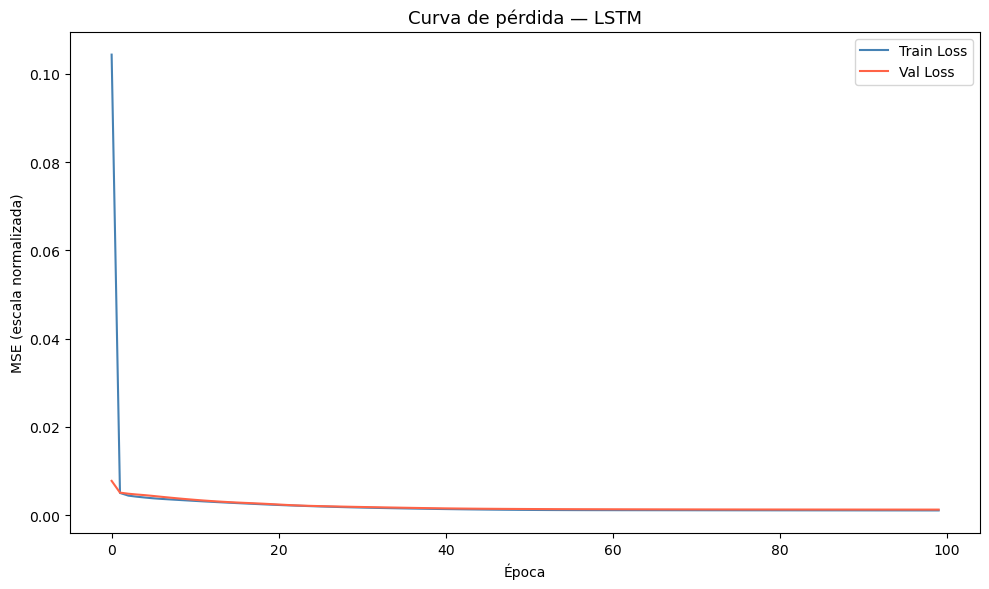

In [79]:
# Curva de pérdida
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax.set_title('Curva de pérdida — LSTM', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
plt.tight_layout()
plt.show()

In [80]:
# Predicciones
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm_real   = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

# Métricas
mae_lstm   = mean_absolute_error(y_test_real, y_pred_lstm_real)
rmse_lstm  = np.sqrt(mean_squared_error(y_test_real, y_pred_lstm_real))


print(f'MAE  : {mae_lstm:.4f} USD')
print(f'RMSE : {rmse_lstm:.4f} USD')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE  : 27.4734 USD
RMSE : 39.6525 USD


Ahora vemos las predicciones de la LSTM en los últimos 100 días apartados:

In [81]:
X_fin_lstm        = X_fin.reshape(X_fin.shape[0], tiempo, 1)
y_fin_lstm_scaled = lstm_model.predict(X_fin_lstm).flatten()
y_fin_lstm_real   = scaler.inverse_transform(y_fin_lstm_scaled.reshape(-1, 1)).flatten()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


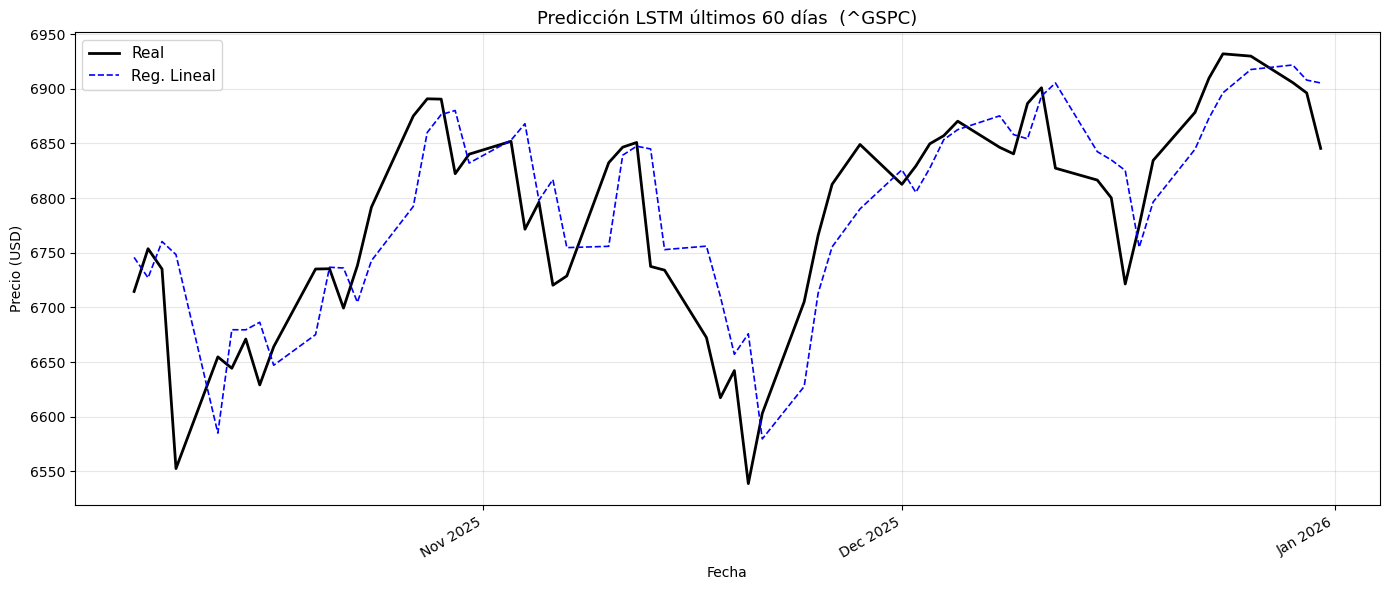

In [82]:
ig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_fin_pred, y_fin_real,      color='black',  linewidth=2,   label='Real')
ax.plot(dates_fin_pred, y_fin_lstm_real,   color='blue',  linewidth=1.2, linestyle='--', label='Reg. Lineal')

ax.set_title(f'Predicción LSTM últimos {test_final} días  ({ticker})', fontsize=13)
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vemos ambas gráficas juntas:

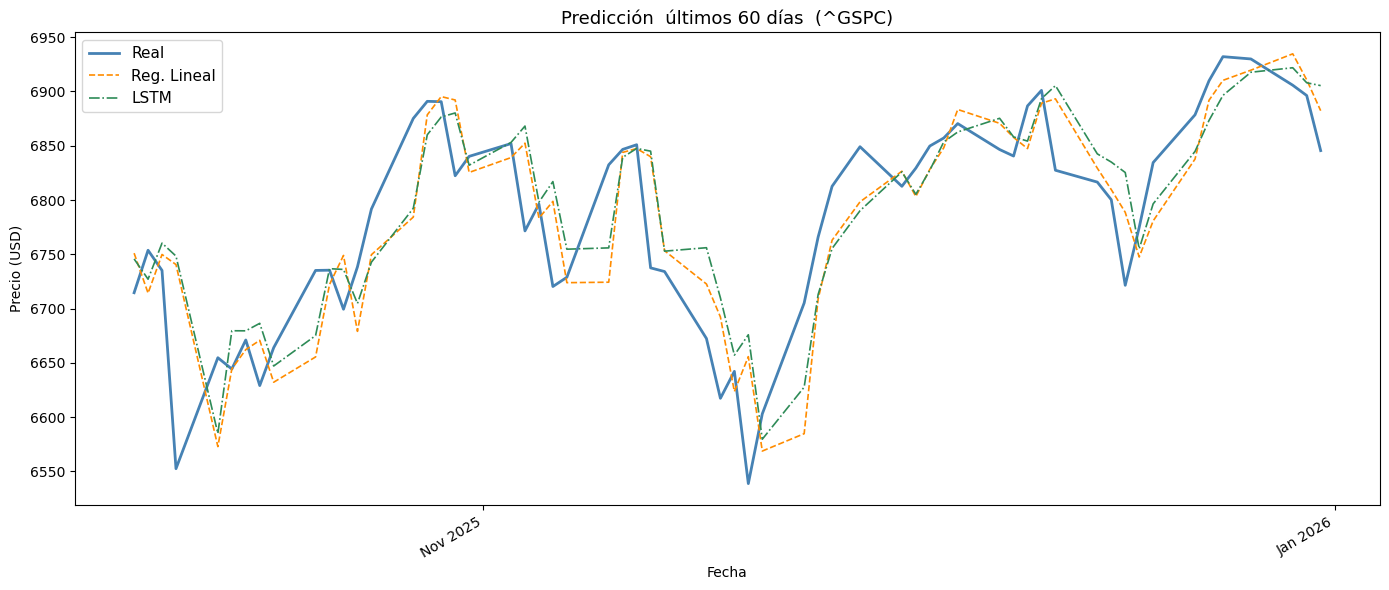

In [83]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_fin_pred, y_fin_real,      color='steelblue',  linewidth=2,   label='Real')
ax.plot(dates_fin_pred, y_fin_lr_real,   color='darkorange', linewidth=1.2, linestyle='--', label='Reg. Lineal')
ax.plot(dates_fin_pred, y_fin_lstm_real, color='seagreen',   linewidth=1.2, linestyle='-.',  label='LSTM')

ax.set_title(f'Predicción  últimos {test_final} días  ({ticker})', fontsize=13)
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## EXPERIMENTO 3: GRU

La GRU es una variante simplificada de la LSTM. El preprocesamiento es idéntico al de los experimentos anteriores (mismas secuencias, mismo scaler, misma división train/test).

In [84]:

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(tiempo, 1)),
    GRU(32, return_sequences=False),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
early_stop_gru = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_gru = gru_model.fit(
    X_train_lstm, y_train,          # misma forma (samples, tiempo, 1)
    epochs=100,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop_gru],
    verbose=1
)


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1660 - val_loss: 0.0043
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0044 - val_loss: 0.0034
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0

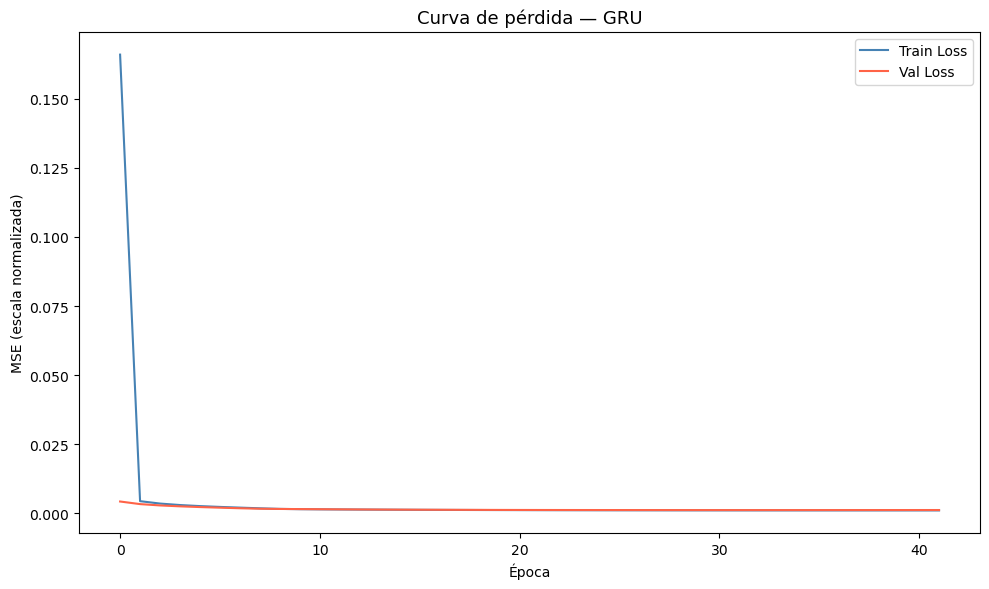

In [86]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(history_gru.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history_gru.history['val_loss'], label='Val Loss',   color='tomato')
ax.set_title('Curva de pérdida — GRU', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
plt.tight_layout()
plt.show()


In [87]:
y_pred_gru_scaled = gru_model.predict(X_test_lstm).flatten()
y_pred_gru_real   = scaler.inverse_transform(y_pred_gru_scaled.reshape(-1, 1)).flatten()

mae_gru  = mean_absolute_error(y_test_real, y_pred_gru_real)
rmse_gru = np.sqrt(mean_squared_error(y_test_real, y_pred_gru_real))

print(f'MAE  : {mae_gru:.4f} USD')
print(f'RMSE : {rmse_gru:.4f} USD')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE  : 26.6093 USD
RMSE : 39.5755 USD


Predicción de la GRU en los últimos 100 días apartados:

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


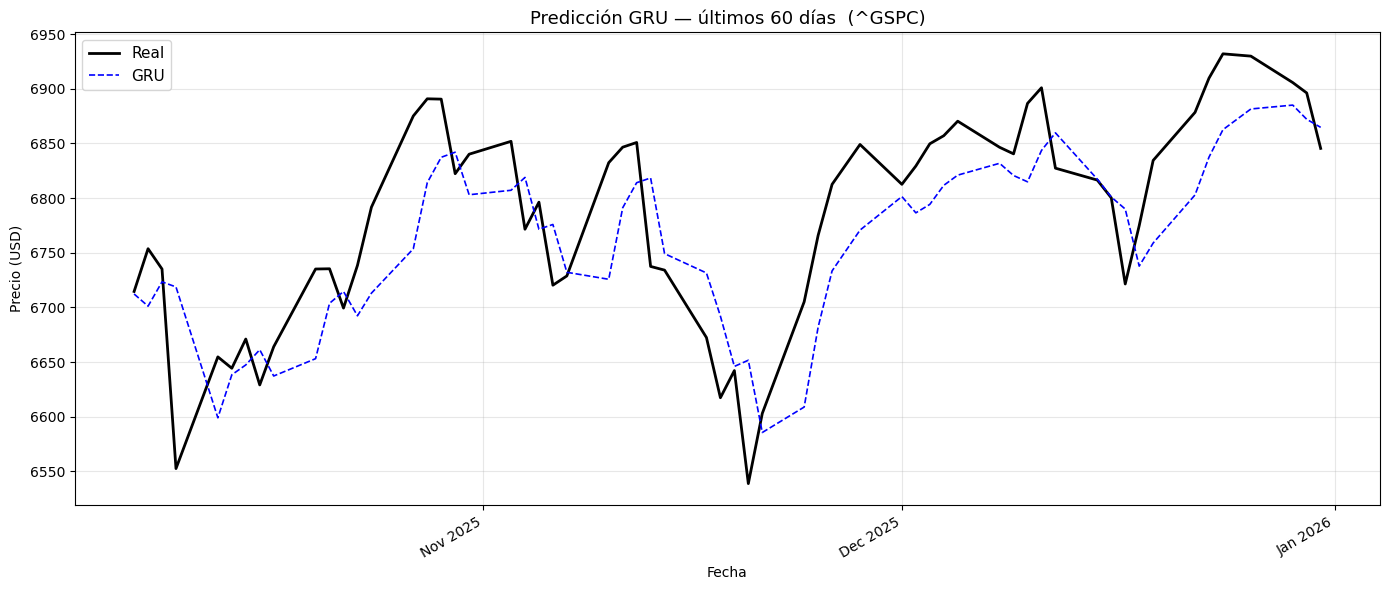

In [88]:
y_fin_gru_scaled = gru_model.predict(X_fin_lstm).flatten()
y_fin_gru_real   = scaler.inverse_transform(y_fin_gru_scaled.reshape(-1, 1)).flatten()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_fin_pred, y_fin_real,     color='black', linewidth=2,   label='Real')
ax.plot(dates_fin_pred, y_fin_gru_real, color='blue', linewidth=1.2, linestyle='--', label='GRU')
ax.set_title(f'Predicción GRU — últimos {test_final} días  ({ticker})', fontsize=13)
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

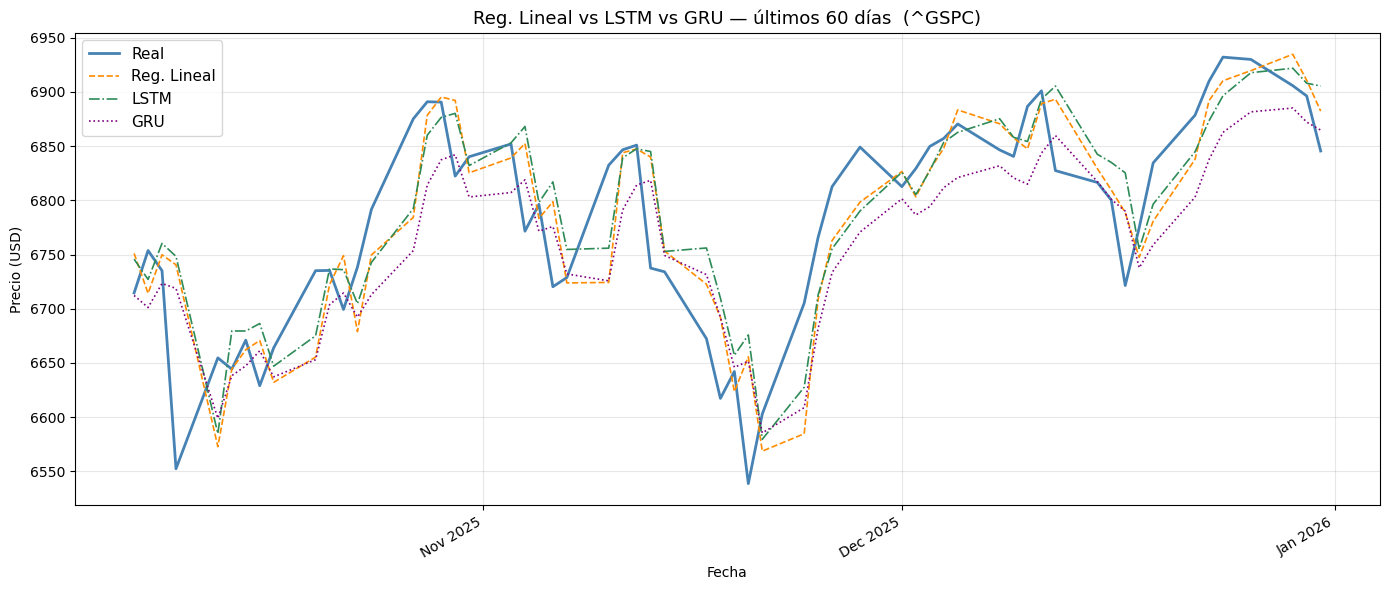

In [91]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_fin_pred, y_fin_real,      color='steelblue',  linewidth=2,   label='Real')
ax.plot(dates_fin_pred, y_fin_lr_real,   color='darkorange', linewidth=1.2, linestyle='--',  label='Reg. Lineal')
ax.plot(dates_fin_pred, y_fin_lstm_real, color='seagreen',   linewidth=1.2, linestyle='-.',  label='LSTM')
ax.plot(dates_fin_pred, y_fin_gru_real,  color='purple',     linewidth=1.2, linestyle=':',   label='GRU')

ax.set_title(f'Reg. Lineal vs LSTM vs GRU — últimos {test_final} días  ({ticker})', fontsize=13)
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## CONCLUSIONES

Observamos que las RNN no logran superar a la regresión lineal. Esto se debe a que los precios de cierre de un día y el siguiente tienen una relación prácticamente lineal. Esto hace que la regresión lineal se ajuste bastante bien, y que los modelos más complejos (como son las redes neuronales) intenten buscar otros patrones inexistentes, introduciendo ruido en las predicciones.